In [1]:
import pandas as pd

# 상대 경로 직접 사용 (notebook 위치 기준)
df = pd.read_csv('../../../../../data/processed_office_data.csv')

print(f"데이터 로드 완료: {len(df)} rows")
df.head()

데이터 로드 완료: 387 rows


,등록번호,중개사명,대표자,전화번호,주소,거래완료,등록매물,개설시작일,개설종료일,등록일,...,지역명,도로명주소코드,최종수정일,총_직원수,공인중개사수,중개보조원수,대표수,일반직원수,직원목록_JSON,직원명단
0,11170-2015-00203,태진공인중개사사무소,김태진,02-794-3900,서울특별시 용산구 남영동 83-1 1층,161건,10건,2025-10-05,2026-10-04,2002-10-05,...,서울특별시 용산구,11170200500500027000000,2025-12-02,2,1,1,1,1,"[{""이름"": ""김정숙"", ""구분코드"": 4.0, ""구분명"": ""중개보조원"", ""자...","김정숙, 김태진"
1,11170-2017-00092,용산센트럴드림부동산공인중개사사무소,안지선,010-9234-9833,"서울 용산구 서빙고로 17, 판매시설동 1층 28호(한강로3가, 용산센트럴파크해링턴...",0건,1건,2025-06-12,2026-06-11,2017-06-11,...,서울특별시 용산구,11170310200400001700000,2025-12-02,4,1,3,1,3,"[{""이름"": ""김형진"", ""구분코드"": 4.0, ""구분명"": ""중개보조원"", ""자...","김형진, 안지선, 유현석, 이동혁"
2,11170-2018-00164,명성공인중개사사무소,이민경,02-719-8945,서울특별시 용산구 효창원로 240 1층(청파동1가),76건,5건,2025-09-27,2026-09-26,2018-09-27,...,서울특별시 용산구,1117030050220024000000,2025-12-02,1,1,0,1,0,"[{""이름"": ""이민경"", ""구분코드"": 2.0, ""구분명"": ""공인중개사"", ""자...",이민경
3,11170-2019-00067,하늘공인중개사사무소,김현호,02-776-7009,서울특별시 용산구 용산동2가 1-76 3층,403건,12건,2025-04-25,2026-04-24,2019-04-25,...,서울특별시 용산구,11170410617200003800000,2025-12-02,2,1,1,1,1,"[{""이름"": ""김진애"", ""구분코드"": 4.0, ""구분명"": ""중개보조원"", ""자...","김진애, 김현호"
4,11170-2020-00099,엘공인중개사사무소,김현임,02-772-9989,서울특별시 용산구 후암로23길 31 1층,152건,12건,2025-07-29,2026-07-28,2020-07-29,...,서울특별시 용산구,11170410657600003100000,2025-12-02,1,1,0,1,0,"[{""이름"": ""김현임"", ""구분코드"": 2.0, ""구분명"": ""공인중개사"", ""자...",김현임


In [2]:
df_nan = df[df["거래완료"].isna() & df["등록매물"].isna()]
df_nan

,등록번호,중개사명,대표자,전화번호,주소,거래완료,등록매물,개설시작일,개설종료일,등록일,...,지역명,도로명주소코드,최종수정일,총_직원수,공인중개사수,중개보조원수,대표수,일반직원수,직원목록_JSON,직원명단


   거래완료  등록매물  전체매물     거래성사율
0   161    10   171  0.941520
1     0     1     1  0.000000
2    76     5    81  0.938272
3   403    12   415  0.971084
4   152    12   164  0.926829


C:\Users\Playdata\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Playdata\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Playdata\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Playdata\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Playdata\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWa

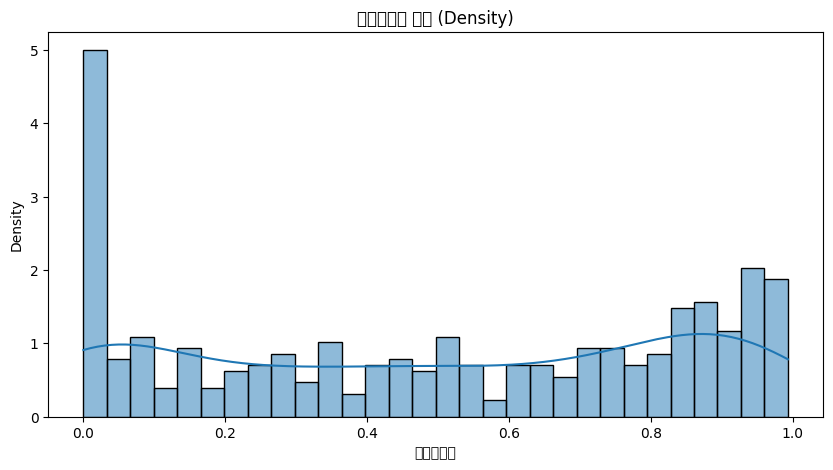

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 숫자 변환 (예: "51건", "9건" → 51, 9)
def to_int(x):
    if isinstance(x, str):
        return int(x.replace("건", "").strip())
    return x

df["거래완료"] = df["거래완료"].apply(to_int)
df["등록매물"] = df["등록매물"].apply(to_int)

# 2. 전체 매물 (거래완료 + 등록매물)
df["전체매물"] = df["거래완료"] + df["등록매물"]

# 3. 거래성사율 계산 (0으로 나누기 방지)
df["거래성사율"] = df["거래완료"] / (df["전체매물"] + 1e-6)

print(df[["거래완료", "등록매물", "전체매물", "거래성사율"]].head())

# 4. 정규분포(히스토그램 + KDE 곡선)
plt.figure(figsize=(10, 5))
sns.histplot(df["거래성사율"], bins=30, kde=True, stat="density")
plt.title("거래성사율 분포 (Density)")
plt.xlabel("거래성사율")
plt.ylabel("Density")
plt.show()


In [5]:
from sklearn.cluster import KMeans
import numpy as np

vals = df["거래성사율"].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=3, random_state=42).fit(vals)
df["cluster"] = kmeans.labels_

In [9]:
# 각 클러스터별 통계
print(df.groupby("cluster")["거래성사율"].describe())

# 각 클러스터에 몇 개씩 있는지
print(df["cluster"].value_counts())

         count      mean       std       min       25%       50%       75%  \
cluster                                                                      
0        119.0  0.059851  0.072683  0.000000  0.000000  0.029126  0.111111   
1        163.0  0.848610  0.100733  0.641509  0.768480  0.863636  0.933120   
2        105.0  0.428790  0.113843  0.246753  0.333333  0.437500  0.510526   

              max  
cluster            
0        0.236220  
1        0.992958  
2        0.636364  
cluster
1    163
0    119
2    105
Name: count, dtype: int64


In [10]:
# 클러스터별 평균 거래성사율
cluster_means = df.groupby("cluster")["거래성사율"].mean().sort_values()
print(cluster_means)

# 클러스터 이름 붙이기 (예: 저성과, 중성과, 고성과)
df["성과등급"] = df["cluster"].map({
    cluster_means.index[0]: "저성과",
    cluster_means.index[1]: "중성과", 
    cluster_means.index[2]: "고성과"
})


cluster
0    0.059851
2    0.428790
1    0.848610
Name: 거래성사율, dtype: float64


In [11]:
# 각 클러스터의 실제 상황 확인
for i in [0, 2, 1]:
    print(f"\n=== Cluster {i} (거래성사율: {df[df['cluster']==i]['거래성사율'].mean():.1%}) ===")
    cluster_data = df[df["cluster"] == i]
    print(f"중개사 수: {len(cluster_data)}개")
    print(f"평균 거래완료: {cluster_data['거래완료'].mean():.1f}건")
    print(f"평균 등록매물: {cluster_data['등록매물'].mean():.1f}건")
    print(f"평균 전체매물: {cluster_data['전체매물'].mean():.1f}건")
    
    # 샘플 몇 개 보기
    print("\n샘플:")
    print(cluster_data[["중개사명", "거래완료", "등록매물", "거래성사율"]].head(3))



=== Cluster 0 (거래성사율: 6.0%) ===
중개사 수: 119개
평균 거래완료: 5.9건
평균 등록매물: 50.9건
평균 전체매물: 56.8건

샘플:
                 중개사명  거래완료  등록매물     거래성사율
1  용산센트럴드림부동산공인중개사사무소     0     1  0.000000
6          토스부동산중개사무소     1     6  0.142857
7          성심공인중개사사무소     2     9  0.181818

=== Cluster 2 (거래성사율: 42.9%) ===
중개사 수: 105개
평균 거래완료: 46.6건
평균 등록매물: 55.2건
평균 전체매물: 101.8건

샘플:
           중개사명  거래완료  등록매물     거래성사율
10  베스트공인중개사사무소     4    11  0.266667
13   용산공인중개사사무소     6    10  0.375000
14   행운공인중개사사무소    10    10  0.500000

=== Cluster 1 (거래성사율: 84.9%) ===
중개사 수: 163개
평균 거래완료: 377.9건
평균 등록매물: 45.7건
평균 전체매물: 423.7건

샘플:
         중개사명  거래완료  등록매물     거래성사율
0  태진공인중개사사무소   161    10  0.941520
2  명성공인중개사사무소    76     5  0.938272
3  하늘공인중개사사무소   403    12  0.971084
